## Imports & Setup

In [1]:
# Core
import pandas as pd
import numpy as np
import re

# NLP & Features
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sentence_transformers import SentenceTransformer

# Clustering
from sklearn.cluster import KMeans
import hdbscan

# Evaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Utilities
import matplotlib.pyplot as plt

f:\Third Year\FYP New\FYP-Project\MoneyBuddy\finxai_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Final Dataset

In [2]:
DATA_PATH = "Tofinal/final_personal_finance_dataset_v2.csv"

df = pd.read_csv(DATA_PATH)
print(f"[INFO] Loaded rows={len(df):,}, cols={len(df.columns)}")

# Basic cleaning
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date", "Amount"])
df = df.sort_values("Date").reset_index(drop=True)

# Month index (used later)
df["YearMonth"] = df["Date"].dt.to_period("M")

df.head(3)

[INFO] Loaded rows=1,044,771, cols=12


,Date,Transaction Description,Category,Amount,Type,UserID,TransactionID,Currency,Merchant,Account Name,SourceDataset,UnifiedCategory,YearMonth
0,2010-01-01,Online streaming subscription,Entertainment,10.23,Expense,US8028,TRX8_112340,NaN,NaN,NaN,unknown_transactions,Entertainment,2010-01
1,2010-01-01,Movie ticket purchase,Entertainment,11.19,Expense,US8028,TRX8_112699,NaN,NaN,NaN,unknown_transactions,Entertainment,2010-01
2,2010-01-01,Lab test fees,Health,7.17,Expense,US8028,TRX8_112062,NaN,NaN,NaN,unknown_transactions,Bills & Utilities,2010-01


## Text Construction & Normalization

In [3]:
df["raw_text"] = (
    df["Merchant"].fillna("").astype(str) + " " +
    df["Transaction Description"].fillna("").astype(str)
)

df["clean_desc"] = (
    df["raw_text"]
    .str.lower()
    .str.replace(r"[^a-z0-9 ]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"\b\d+\b", "<NUM>", regex=True)
    .str.strip()
)

df[["raw_text", "clean_desc"]].head(5)

,raw_text,clean_desc
0,Online streaming subscription,online streaming subscription
1,Movie ticket purchase,movie ticket purchase
2,Lab test fees,lab test fees
3,Concert or event payment,concert or event payment
4,Bought vegetables and fruits,bought vegetables and fruits


## Lexical Representation — TF-IDF (Character N-grams)

In [4]:
tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2
)

X_tfidf = tfidf.fit_transform(df["clean_desc"])
print("[INFO] TF-IDF shape:", X_tfidf.shape)

[INFO] TF-IDF shape: (1044771, 11904)


## Dimensionality Reduction (Truncated SVD)

In [5]:
SVD_DIM = 200

svd = TruncatedSVD(n_components=SVD_DIM, random_state=42)
X_tfidf_reduced = svd.fit_transform(X_tfidf)

print("[INFO] Reduced TF-IDF shape:", X_tfidf_reduced.shape)
print("[INFO] Explained variance:", svd.explained_variance_ratio_.sum())

[INFO] Reduced TF-IDF shape: (1044771, 200)
[INFO] Explained variance: 0.9984407741216756


## Semantic Representation — SBERT

In [6]:
sbert = SentenceTransformer("all-MiniLM-L6-v2")

X_sbert = sbert.encode(
    df["clean_desc"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

print("[INFO] SBERT shape:", X_sbert.shape)

Batches: 100%|██████████| 32650/32650 [43:54<00:00, 12.39it/s]    


[INFO] SBERT shape: (1044771, 384)


## Hybrid Transaction Embedding

In [7]:
X = np.hstack([X_tfidf_reduced, X_sbert])
print("[INFO] Final feature shape:", X.shape)

[INFO] Final feature shape: (1044771, 584)


## Clustering — KMeans (Primary Model)

In [8]:
K = 25

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

df["ClusterID"] = kmeans.fit_predict(X)

print("[INFO] Clusters formed:", df["ClusterID"].nunique())

[INFO] Clusters formed: 25


## Cluster Size Distribution

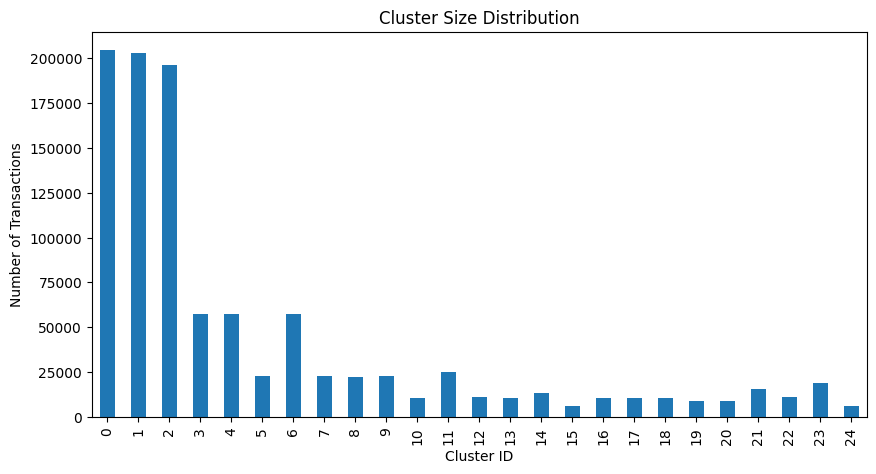

In [9]:
cluster_sizes = df["ClusterID"].value_counts().sort_index()

plt.figure(figsize=(10,5))
cluster_sizes.plot(kind="bar")
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Transactions")
plt.show()

## Human Interpretability Check

In [10]:
def inspect_cluster(cid, n=5):
    print(f"\n=== Cluster {cid} ===")
    samples = (
        df[df["ClusterID"] == cid]["clean_desc"]
        .sample(n, random_state=42)
        .values
    )
    for s in samples:
        print("-", s)

for cid in range(5):
    inspect_cluster(cid)


=== Cluster 0 ===
- movie ticket purchase
- movie ticket purchase
- movie ticket purchase
- movie ticket purchase
- lottery ticket purchase

=== Cluster 1 ===
- online streaming subscription
- online streaming subscription
- online streaming subscription
- online streaming subscription
- online streaming subscription

=== Cluster 2 ===
- concert or event payment
- concert or event payment
- concert or event payment
- concert or event payment
- concert or event payment

=== Cluster 3 ===
- bought vegetables and fruits
- bought vegetables and fruits
- bought vegetables and fruits
- bought vegetables and fruits
- bought vegetables and fruits

=== Cluster 4 ===
- grocery shopping at supermarket
- grocery shopping at supermarket
- grocery shopping at supermarket
- grocery shopping at supermarket
- grocery shopping at supermarket


## Canonical Merchant per Cluster

In [11]:
cluster_exemplars = (
    df.groupby("ClusterID")["Merchant"]
      .agg(lambda x: x.value_counts().index[0] if x.notna().any() else "Unknown")
      .to_dict()
)

df["CanonicalMerchant"] = df["ClusterID"].map(cluster_exemplars)

df[["ClusterID", "CanonicalMerchant"]].drop_duplicates().head(10)

,ClusterID,CanonicalMerchant
0,1,AMC Theatres
1,0,AMC Theatres
2,21,Local Clinic
3,2,Spotify
4,3,Vegetables
6,7,Uber
9,12,Mobile Carrier
12,6,Unknown
13,4,Walmart
20,5,Bike


## Cluster Validation Metrics

In [12]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

# -------------------------------
# SAFE SAMPLING (REQUIRED)
# -------------------------------
SAMPLE_SIZE = 50_000    

np.random.seed(42)
sample_idx = np.random.choice(len(X), size=SAMPLE_SIZE, replace=False)

X_sample = X[sample_idx]
labels_sample = df.loc[sample_idx, "ClusterID"]

# -------------------------------
# CLUSTER VALIDATION (FAST)
# -------------------------------
sil = silhouette_score(X_sample, labels_sample)
dbi = davies_bouldin_score(X_sample, labels_sample)

print(f"Silhouette Score (sampled): {sil:.4f}")
print(f"Davies-Bouldin Index (sampled): {dbi:.4f}")

Silhouette Score (sampled): 0.9398
Davies-Bouldin Index (sampled): 0.9387


## HDBSCAN (Comparison)

In [13]:
# hdb = hdbscan.HDBSCAN(
#     min_cluster_size=100,
#     metric="euclidean"
# )

# hdb_labels = hdb.fit_predict(X)

# print("HDBSCAN clusters:", len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0))
# print("Noise ratio:", (hdb_labels == -1).mean())

In [14]:
# SAFE SAMPLING
SAMPLE_SIZE = 30_000   # 20k–50k max
np.random.seed(42)

sample_idx = np.random.choice(len(X), size=SAMPLE_SIZE, replace=False)
X_sample = X[sample_idx]

# Run HDBSCAN on sample
hdb = hdbscan.HDBSCAN(
    min_cluster_size=100,
    metric="euclidean",
    core_dist_n_jobs=1   # safer on Windows
)

hdb_labels = hdb.fit_predict(X_sample)

print("HDBSCAN clusters (sample):",
      len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0))
print("Noise ratio (sample):", (hdb_labels == -1).mean())

f:\Third Year\FYP New\FYP-Project\MoneyBuddy\finxai_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
f:\Third Year\FYP New\FYP-Project\MoneyBuddy\finxai_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN clusters (sample): 32
Noise ratio (sample): 0.006533333333333334



## Save Model

In [15]:
import joblib, os

os.makedirs("models", exist_ok=True)

joblib.dump(tfidf, "models/tfidf.pkl")
joblib.dump(svd, "models/svd.pkl")
joblib.dump(sbert, "models/sbert.pkl")
joblib.dump(kmeans, "models/kmeans.pkl")

print("[INFO] Model artifacts saved.")

[INFO] Model artifacts saved.
